# 02 Applies both K-Means and hierarchical clustering directly on the PF-time series for the selected dataset.

Three datasets are available via the `dataset_chosen` key:

| key | description |
|---|---|
|`Slovakia`| Slovakian dataset with 1000 buildings measured in 2016|
|`Germany`| German dataset with 38 buildings measured from 2018 till 2020|
|`USA`| MFRED (USA) dataset with 26 buildings measured from 2019 till 2021|

> **Note:** The file can be manually followed sequentially to train or test the clustering method.

In [1]:
import numpy as np
from pathlib import Path
import importlib
import pandas as pd


import sys
sys.path.append("..")


## 2.1 Selecting the input parameters.

In order to consider different scenarios, the relevant input parameters are given selected via their respective keys.

| keys | values | description |
|---|---|---|
|`dataset_chosen`|`Slovakia`, `Germany`, `USA`| Selects the dataset on which to do the analysis.|
|`trainVsTest`| `Train`, `Test`| Trains or tests the clustering algorithm.|
|`MAEVsRMSE`| `MAE`, `RMSE`| Uses MAE or RMSE metric|
|`Clustering_method`|`KMeans`, `hierarchical`| Selects between K-Means or hierarchical clustering.|
|`input_period`|`year`, `month`, `seasonal`| Selects the input period to consider.|
|`resolution`|`15_min`, `hourly`, `daily`| Selects the resolution to consider.|

> **Note:** The input periods to select from consider the full year (`year`) of data, consider the most representative month (`month`) of data, or consider each full season separately (`seasonal`).

In [34]:
dataset_chosen = "USA"
trainVsTest = "Test"
MAEVsRMSE = "RMSE"
Clustering_method = "hierarchical"
input_period = "seasonal"
resolution = "15_min"

## 2.2 Loading in the cleaned data.

In [35]:
import general_clustering_functions as gcf
project_root = Path().resolve()

if dataset_chosen == "Slovakia":
    path_folder = project_root / "data" / "repository" / "Slovakia"
elif dataset_chosen == "Germany":
    path_folder = project_root / "data" / "repository" / "Germany"
elif dataset_chosen == "USA":
    path_folder = project_root / "data" / "repository" / "USA"

if trainVsTest == "Train":
    power_dict, houses = gcf.loading_cleaned_files(path_folder, "power_dict_train.zip", dataset_chosen)
elif trainVsTest == "Test":
    power_dict, houses = gcf.loading_cleaned_files(path_folder, "power_dict_test.zip", dataset_chosen)
print(power_dict[list(power_dict.keys())[0]].head())

Error removing C:\Users\u0181580\OneDrive - KU Leuven\PHD\Julia\clean_code_thesis\clustering\data\repository\USA\extracted_dataframes: (<class 'PermissionError'>, PermissionError(13, 'Toegang geweigerd'), <traceback object at 0x0000026BF4D4CB40>)
                           Nr       P       Q         S        PF  PV
DateTimeUTC                                                          
2021-01-01 00:00:00-05:00   1  0.0229  0.0039  0.023230  0.985806   0
2021-01-01 00:15:00-05:00   1  0.0378  0.0120  0.039659  0.953124   0
2021-01-01 00:30:00-05:00   1  0.0267  0.0003  0.026702  0.999937   0
2021-01-01 00:45:00-05:00   1  0.0256  0.0027  0.025742  0.994484   0
2021-01-01 01:00:00-05:00   1  0.0349  0.0053  0.035300  0.988665   0


## 2.3 Calculate the base case accuracy for the given dataset

In [36]:
best_PF, basecase = gcf.basecase(power_dict, MAEVsRMSE)
print(f"Best PF: {best_PF}, Basecase error: {basecase}")

[0.32044, 0.3085, 0.29657, 0.28464, 0.27267, 0.26064, 0.24853, 0.2363, 0.22392, 0.21134, 0.19851, 0.18536, 0.17183, 0.1578, 0.14315, 0.1277, 0.11123, 0.09347, 0.07446, 0.06622]
Best PF: 1.0, Basecase error: 0.06622


## 2.4 Preprocessing data for clustering
The first block adapts the data resolution, the second selects the considered input period. The third block creates and normalizes the data array

In [37]:
power_dict_timed, month_length_31, Summer_length, Winter_length, Fall_length, Spring_length = gcf.adapting_data_resolution(power_dict, resolution, dataset_chosen)

In [49]:
import clustering_on_PF_time_series_functions as cptf

if input_period == "month":
    representative_month, representative_month_index = cptf.representative_month(power_dict_timed, month_length_31, MAEVsRMSE)
elif input_period == "seasonal":
    Summer_data_timed_PF, Fall_data_timed_PF, Winter_data_timed_PF, Spring_data_timed_PF, Summer_data, Fall_data, Winter_data, Spring_data = gcf.creating_season_data(power_dict_timed, power_dict, Summer_length, Winter_length, Fall_length, Spring_length, dataset_chosen, "PF", "PF_time")
    Summer_data_timed_P, Fall_data_timed_P, Winter_data_timed_P, Spring_data_timed_P, Summer_data, Fall_data, Winter_data, Spring_data = gcf.creating_season_data(power_dict_timed, power_dict, Summer_length, Winter_length, Fall_length, Spring_length, dataset_chosen, "P", "PF_time")
    Summer_data_timed_Q, Fall_data_timed_Q, Winter_data_timed_Q, Spring_data_timed_Q, Summer_data, Fall_data, Winter_data, Spring_data = gcf.creating_season_data(power_dict_timed, power_dict, Summer_length, Winter_length, Fall_length, Spring_length, dataset_chosen, "Q", "PF_time")

In [ ]:
if input_period == "year":
    power_factor_array = cptf.array_normalization(power_dict_timed, 0)
elif input_period == "month":
    power_factor_array = cptf.array_normalization(representative_month, 1)
elif input_period == "seasonal":
    power_factor_array_Summer = cptf.array_normalization(Summer_data_timed_PF, 2)
    power_factor_array_Fall = cptf.array_normalization(Fall_data_timed_PF, 2)
    power_factor_array_Winter = cptf.array_normalization(Winter_data_timed_PF, 2)
    power_factor_array_Spring = cptf.array_normalization(Spring_data_timed_PF, 2)


(26, 8832)
(26, 8740)
(26, 8640)
(26, 8828)


## 2.5 Training of K-Means or Hierarchical clustering hyperparameters

In [40]:
if trainVsTest == "Train":
    if Clustering_method == "KMeans":
        if input_period == "seasonal":
            silhouette_summer, inertia_summer = gcf.cluster_elbow_decision(power_factor_array_Summer, dataset_chosen, "PF_time")
            silhouette_fall, inertia_fall = gcf.cluster_elbow_decision(power_factor_array_Fall, dataset_chosen, "PF_time")
            silhouette_winter, inertia_winter = gcf.cluster_elbow_decision(power_factor_array_Winter, dataset_chosen, "PF_time")
            silhouette_spring, inertia_spring = gcf.cluster_elbow_decision(power_factor_array_Spring, dataset_chosen, "PF_time")
        else:
            silhouette, inertia = gcf.cluster_elbow_decision(power_factor_array, dataset_chosen, "PF_time")
    elif Clustering_method == "hierarchical":
        if input_period == "seasonal":
            silhouette_summer, inertia_summer = gcf.cluster_hier_decision(power_factor_array_Summer, dataset_chosen)
            silhouette_fall, inertia_fall = gcf.cluster_hier_decision(power_factor_array_Fall, dataset_chosen)
            silhouette_winter, inertia_winter = gcf.cluster_hier_decision(power_factor_array_Winter, dataset_chosen)
            silhouette_spring, inertia_spring = gcf.cluster_hier_decision(power_factor_array_Spring, dataset_chosen)
        else:
            silhouette, inertia = gcf.cluster_hier_decision(power_factor_array, dataset_chosen)
else:
    print("No need to find the optimal number of clusters for the test set, as it is already known from the training set.")

No need to find the optimal number of clusters for the test set, as it is already known from the training set.


The following block allows to manually fill in the number of clusters you found optimal from the previous outputs.

In [41]:
if trainVsTest == "Train":
    if input_period == "seasonal":
        num_clusters_summer = 5
        num_clusters_fall = 5
        num_clusters_winter = 5
        num_clusters_spring = 5
    else:
        num_clusters = 5
else:
    if MAEVsRMSE == "MAE":
        print("Testing is not defined for the MAE metric")
    else:
        Num_clusters, random_state, num_PCA_components, correlating_features = gcf.reading_hyperparameters("PF_time", path_folder, dataset_chosen, Clustering_method, resolution, input_period)
        if input_period == "seasonal":
            num_clusters_summer = Num_clusters[0]
            num_clusters_fall = Num_clusters[1]
            num_clusters_winter = Num_clusters[2]
            num_clusters_spring = Num_clusters[3]
        else:
            num_clusters = Num_clusters[0]


    print(f"Number of clusters: {Num_clusters}, Random state: {random_state}, Number of PCA components: {num_PCA_components}, Correlating features: {correlating_features}")

Number of clusters: [3, 5, 4, 4], Random state: [0], Number of PCA components: [0], Correlating features: [0]


Finds the best initialization point for KMeans clustering based on the selected number of clusters.

In [42]:
if Clustering_method == "KMeans": 
    if trainVsTest == "Train":
        if input_period == "seasonal":
            random_state_summer = gcf.find_random_state(power_factor_array_Summer, num_clusters_summer, "PF_time")
            random_state_fall = gcf.find_random_state(power_factor_array_Fall, num_clusters_fall, "PF_time")
            random_state_winter = gcf.find_random_state(power_factor_array_Winter, num_clusters_winter, "PF_time")
            random_state_spring = gcf.find_random_state(power_factor_array_Spring, num_clusters_spring, "PF_time")
        else:
            random_state = gcf.find_random_state(power_factor_array, num_clusters, "PF_time")
    else:
        if input_period == "seasonal":
            random_state_summer = random_state[0]
            random_state_fall = random_state[1]
            random_state_winter = random_state[2]
            random_state_spring = random_state[3]
        else:
            random_state = random_state[0]
else:
    random_state = 0

## 2.6 Clustering the data

In [43]:
if Clustering_method == "KMeans":
    if input_period == "seasonal":
        labeled_houses_summer, silhouette_summer = gcf.cluster_kmeans(power_factor_array_Summer, num_clusters_summer, random_state_summer, houses, "PF_time")
        labeled_houses_fall, silhouette_fall = gcf.cluster_kmeans(power_factor_array_Fall, num_clusters_fall, random_state_fall, houses, "PF_time")
        labeled_houses_winter, silhouette_winter = gcf.cluster_kmeans(power_factor_array_Winter, num_clusters_winter, random_state_winter, houses, "PF_time")
        labeled_houses_spring, silhouette_spring = gcf.cluster_kmeans(power_factor_array_Spring, num_clusters_spring, random_state_spring, houses, "PF_time")
    else:
        labeled_houses, silhouette = gcf.cluster_kmeans(power_factor_array, num_clusters, random_state, houses, "PF_time")
elif Clustering_method == "hierarchical":
    if input_period == "seasonal":
        labeled_houses_summer, silhouette_summer = gcf.cluster_hierarchical(power_factor_array_Summer, num_clusters_summer, houses)
        labeled_houses_fall, silhouette_fall = gcf.cluster_hierarchical(power_factor_array_Fall, num_clusters_fall, houses)
        labeled_houses_winter, silhouette_winter = gcf.cluster_hierarchical(power_factor_array_Winter, num_clusters_winter, houses)
        labeled_houses_spring, silhouette_spring = gcf.cluster_hierarchical(power_factor_array_Spring, num_clusters_spring, houses)
        silhouette = np.mean([silhouette_summer, silhouette_fall, silhouette_winter, silhouette_spring])
    else:
        labeled_houses, silhouette = gcf.cluster_hierarchical(power_factor_array, num_clusters, houses)

0.5618181778968804
{2: [1], 0: [2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26], 1: [3]}
0.23508799136938274
{4: [1], 0: [2, 5, 6, 7, 8, 9, 12, 13, 14, 15, 16, 18, 21, 24, 25, 26], 2: [3], 1: [4, 11, 17, 19, 20, 22, 23], 3: [10]}
0.21125192361792938
{3: [1], 0: [2, 4, 5, 9, 11, 12, 13, 14, 15, 16, 18, 20, 21, 22, 24, 25, 26], 2: [3, 6, 7, 8], 1: [10, 17, 19, 23]}
0.3244395034513292
{3: [1], 0: [2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17, 18, 20, 21, 22, 24, 25, 26], 2: [10], 1: [19, 23]}


In [44]:
if input_period == 'seasonal':
    groups1_summer = gcf.grouping(labeled_houses_summer, dataset_chosen)
    groups1_fall = gcf.grouping(labeled_houses_fall, dataset_chosen)
    groups1_winter = gcf.grouping(labeled_houses_winter, dataset_chosen)
    groups1_spring = gcf.grouping(labeled_houses_spring, dataset_chosen)
else:
    groups1 = gcf.grouping(labeled_houses, dataset_chosen)

[(0, 24), (1, 1), (2, 1)]
[(0, 16), (1, 7), (2, 1), (3, 1), (4, 1)]
[(0, 17), (1, 4), (2, 4), (3, 1)]
[(0, 22), (1, 2), (2, 1), (3, 1)]


## 2.7 Calculating the estimation accuracy and storing the results

In [67]:
if input_period == 'seasonal':
    min_errors_summer, best_PFs_summer = gcf.error_calc(groups1_summer, Summer_data, MAEVsRMSE)
    min_errors_fall, best_PFs_fall = gcf.error_calc(groups1_fall, Fall_data, MAEVsRMSE)
    min_errors_winter, best_PFs_winter = gcf.error_calc(groups1_winter, Winter_data, MAEVsRMSE)
    min_errors_spring, best_PFs_spring = gcf.error_calc(groups1_spring, Spring_data, MAEVsRMSE)

    Estimation_error = sum(min_errors_summer.values()) + sum(min_errors_fall.values()) + sum(min_errors_winter.values()) + sum(min_errors_spring.values())
else:
    min_errors, best_PFs = gcf.error_calc(groups1, power_dict, MAEVsRMSE)
    Estimation_error = sum(min_errors.values())

if MAEVsRMSE == "MAE":
    Error_tot = Estimation_error/(len(power_dict)*len(power_dict[list(power_dict.keys())[0]]['P']))
else:
    Error_tot = np.sqrt((Estimation_error)/len(power_dict)/len(power_dict[list(power_dict.keys())[0]]['P']))

print(round(Error_tot,5))
improvement = 1 - (Error_tot/basecase)
print(improvement)

2
Minimum Error for rest: 0.01061
Best PF for rest: 0.95
24
Minimum Error for group1: 0.06526
Best PF for group1: 0.99
3
Minimum Error for rest: 0.02613
Best PF for rest: 1.0
16
Minimum Error for group1: 0.05976
Best PF for group1: 0.99
7
Minimum Error for group2: 0.06381
Best PF for group2: 1.0
1
Minimum Error for rest: 0.00984
Best PF for rest: 0.99
17
Minimum Error for group1: 0.05555
Best PF for group1: 1.0
4
Minimum Error for group2: 0.07629
Best PF for group2: 1.0
4
Minimum Error for group3: 0.02411
Best PF for group3: 1.0
2
Minimum Error for rest: 0.03932
Best PF for rest: 1.0
22
Minimum Error for group1: 0.05262
Best PF for group1: 1.0
2
Minimum Error for group2: 0.11037
Best PF for group2: 1.0
0.05858
0.11531423174741162


In [144]:
path_folder = project_root / "data" / "repository"
if trainVsTest == "Train":
    if input_period == "seasonal":
        num_clusters_list = [num_clusters_summer, num_clusters_fall, num_clusters_winter, num_clusters_spring]
        random_state_list = [random_state_summer, random_state_fall, random_state_winter, random_state_spring]
    else:
        num_clusters_list = [num_clusters]
        random_state_list = [random_state]
    gcf.writing_results_training("PF_time", path_folder, dataset_chosen, Clustering_method, resolution, input_period, MAEVsRMSE, improvement, Error_tot, silhouette, num_clusters_list, random_state_list, [0], [0])
else:
    gcf.writing_results_testing("PF_time", path_folder, dataset_chosen, Clustering_method, resolution, input_period, MAEVsRMSE, improvement, Error_tot, silhouette)

## 2.8 Visualizing and interpreting the results

In [68]:
import visualization_results as vr

if input_period == "seasonal":
    PF_list_summer, groups_PF_summer = gcf.grouping_error(labeled_houses_summer, best_PFs_summer, houses, dataset_chosen)
    PF_list_fall, groups_PF_fall = gcf.grouping_error(labeled_houses_fall, best_PFs_fall, houses, dataset_chosen)
    PF_list_winter, groups_PF_winter = gcf.grouping_error(labeled_houses_winter, best_PFs_winter, houses, dataset_chosen)
    PF_list_spring, groups_PF_spring = gcf.grouping_error(labeled_houses_spring, best_PFs_spring, houses, dataset_chosen)

    summer_data_timed_P = {key: df.rename("P") for key, df in Summer_data_timed_P.items()}
    summer_data_timed_Q = {key: df.rename("Q") for key, df in Summer_data_timed_Q.items()}
    fall_data_timed_P = {key: df.rename("P") for key, df in Fall_data_timed_P.items()}
    fall_data_timed_Q = {key: df.rename("Q") for key, df in Fall_data_timed_Q.items()}
    winter_data_timed_P = {key: df.rename("P") for key, df in Winter_data_timed_P.items()}
    winter_data_timed_Q = {key: df.rename("Q") for key, df in Winter_data_timed_Q.items()}
    spring_data_timed_P = {key: df.rename("P") for key, df in Spring_data_timed_P.items()}
    spring_data_timed_Q = {key: df.rename("Q") for key, df in Spring_data_timed_Q.items()}

    Summer_data_timed_error = {key: pd.concat([summer_data_timed_P[key], summer_data_timed_Q[key]], axis=1) for key in summer_data_timed_P}
    Fall_data_timed_error = {key: pd.concat([fall_data_timed_P[key], fall_data_timed_Q[key]], axis=1) for key in fall_data_timed_P}
    Winter_data_timed_error = {key: pd.concat([winter_data_timed_P[key], winter_data_timed_Q[key]], axis=1) for key in winter_data_timed_P}
    Spring_data_timed_error = {key: pd.concat([spring_data_timed_P[key], spring_data_timed_Q[key]], axis=1) for key in spring_data_timed_P}
    tub_error_summer, tub_PF_list_summer = gcf.optimal_error(Summer_data_timed_error, Summer_data, MAEVsRMSE)
    tub_error_fall, tub_PF_list_fall = gcf.optimal_error(Fall_data_timed_error, Fall_data, MAEVsRMSE)
    tub_error_winter, tub_PF_list_winter = gcf.optimal_error(Winter_data_timed_error, Winter_data, MAEVsRMSE)
    tub_error_spring, tub_PF_list_spring = gcf.optimal_error(Spring_data_timed_error, Spring_data, MAEVsRMSE)
else:
    PF_list, groups_PF = gcf.grouping_error(labeled_houses, best_PFs, houses, dataset_chosen)
    tub_error, tub_PF_list = gcf.optimal_error(power_dict_timed, power_dict_timed, power_dict, MAEVsRMSE)

Plotting the relationship between the best power factor (PF) per building and the best PF per cluster.

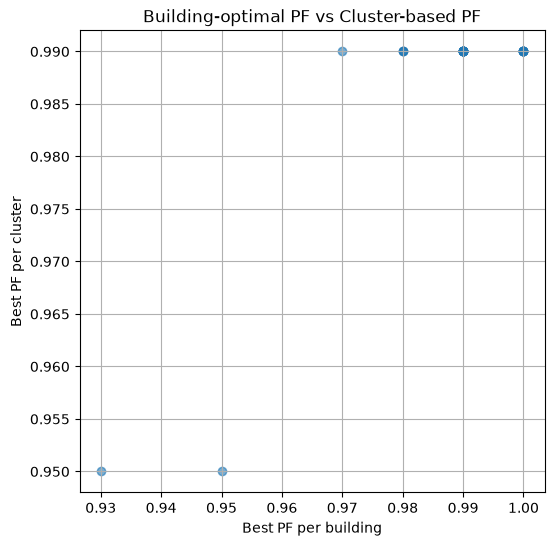

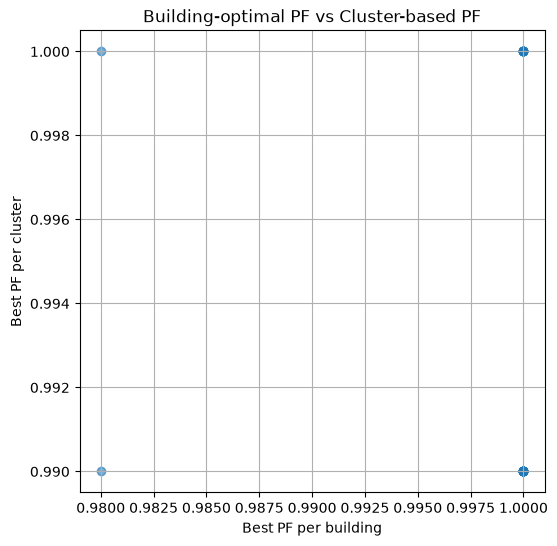

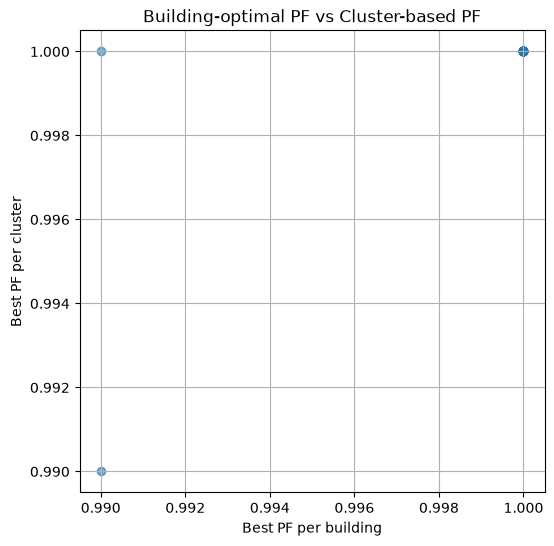

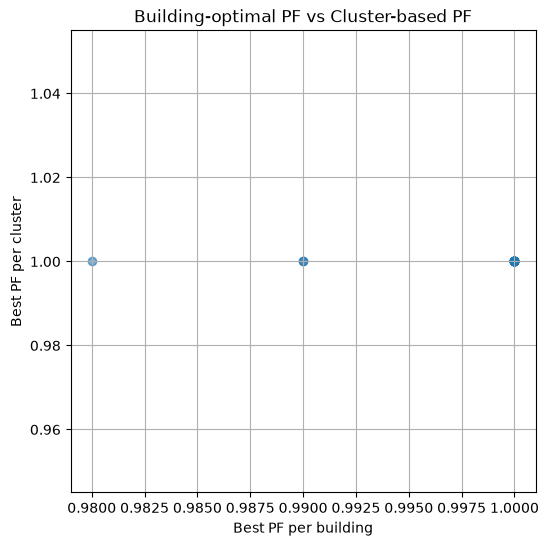

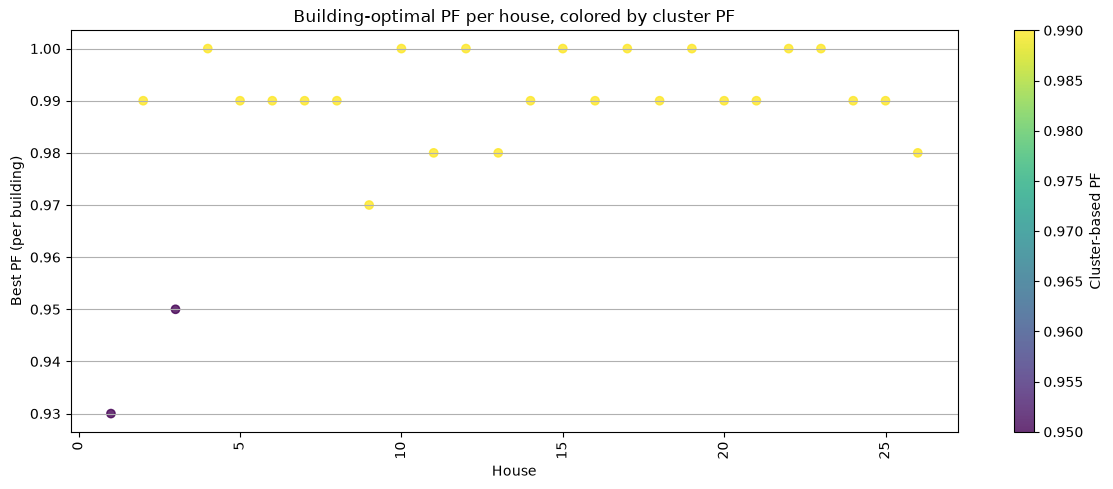

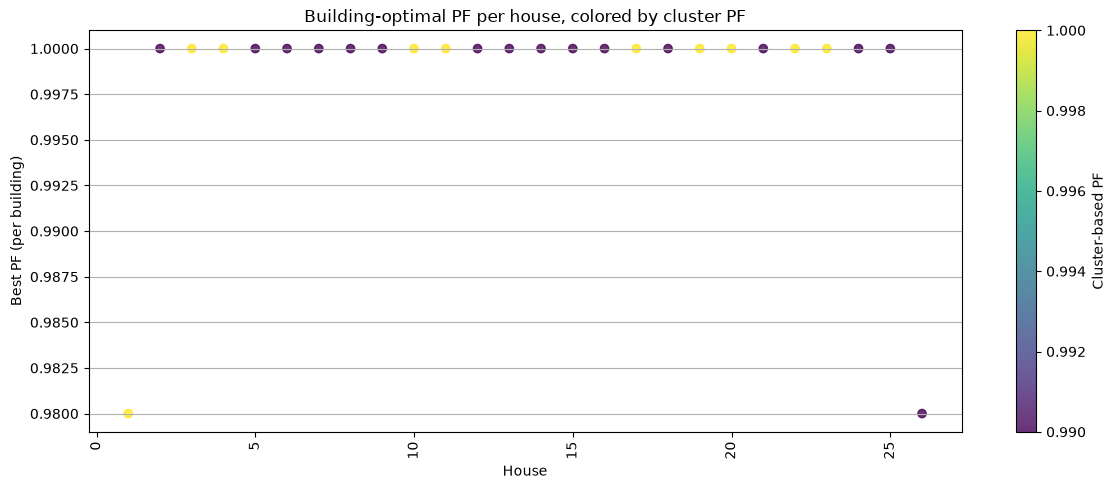

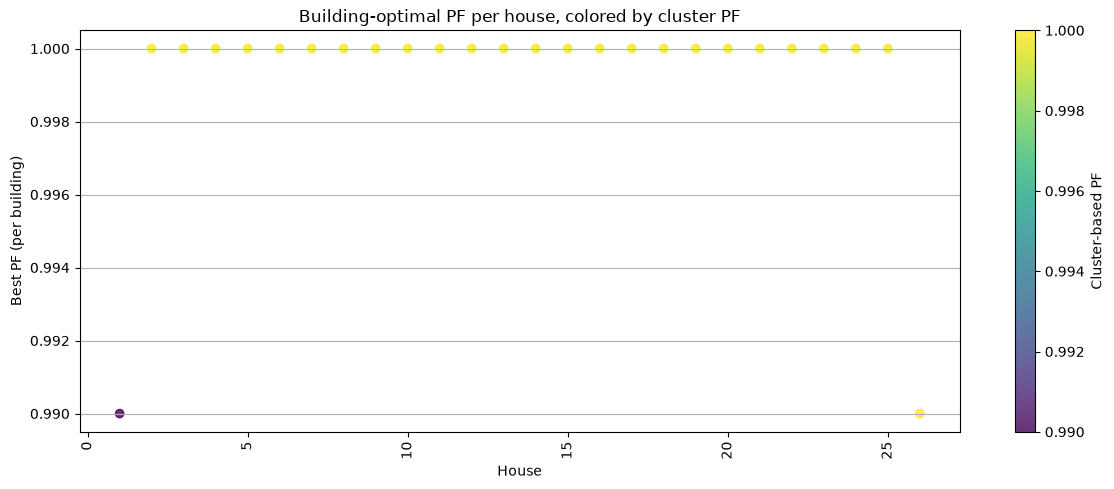

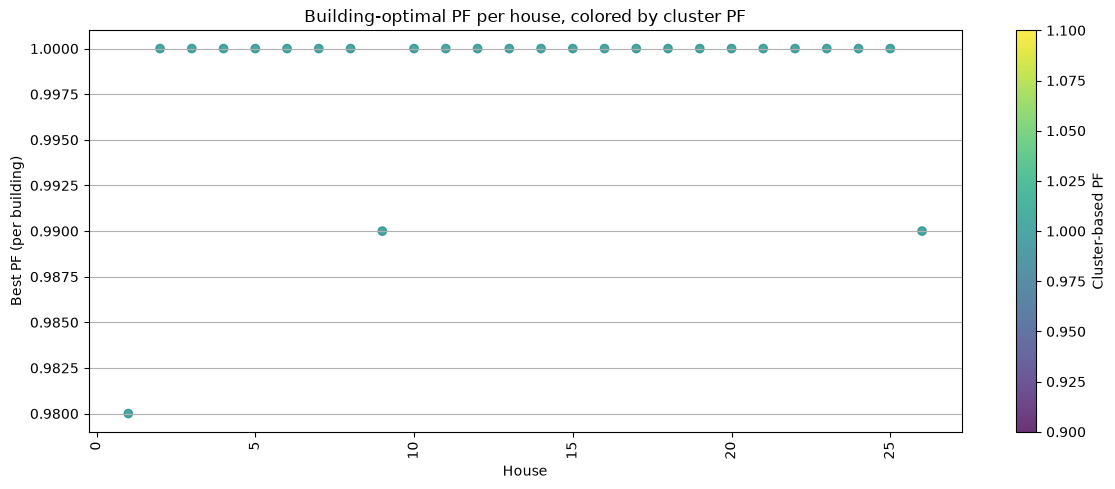

In [69]:
if input_period == "seasonal":
    vr.Optimal_PF_per_cluster(PF_list_summer, tub_PF_list_summer)
    vr.Optimal_PF_per_cluster(PF_list_fall, tub_PF_list_fall)
    vr.Optimal_PF_per_cluster(PF_list_winter, tub_PF_list_winter)
    vr.Optimal_PF_per_cluster(PF_list_spring, tub_PF_list_spring)
    vr.Optimal_PF_per_cluster_buildings(PF_list_summer, tub_PF_list_summer)
    vr.Optimal_PF_per_cluster_buildings(PF_list_fall, tub_PF_list_fall)
    vr.Optimal_PF_per_cluster_buildings(PF_list_winter, tub_PF_list_winter)
    vr.Optimal_PF_per_cluster_buildings(PF_list_spring, tub_PF_list_spring)
else:
    vr.Optimal_PF_per_cluster(PF_list, tub_PF_list)
    vr.Optimal_PF_per_cluster_buildings(PF_list, tub_PF_list)

Prints a table with statistics for each cluster.

In [70]:
if input_period == "seasonal":
    size_distribution_Summer = vr.size_distribution_per_cluster(Summer_data, PF_list_summer, houses)
    size_distribution_Winter = vr.size_distribution_per_cluster(Winter_data, PF_list_winter, houses)
    size_distribution_Fall = vr.size_distribution_per_cluster(Fall_data, PF_list_fall, houses)
    size_distribution_Spring = vr.size_distribution_per_cluster(Spring_data, PF_list_spring, houses)
    print(size_distribution_Summer)
    print(size_distribution_Winter)
    print(size_distribution_Fall)
    print(size_distribution_Spring)
else:
    size_distribution = vr.size_distribution_per_cluster(power_dict, PF_list, houses)
    print(size_distribution)

                             0.95         0.99
Count                    2.000000    24.000000
Avg_size               141.710331  1057.182602
Median_PQ_correlation    0.714528     0.698479
                            0.99        1.00
Count                   1.000000   25.000000
Avg_size               71.082475  708.124499
Median_PQ_correlation   0.335186    0.232284
                             0.99        1.00
Count                   16.000000   10.000000
Avg_size               771.460472  619.301443
Median_PQ_correlation    0.423457    0.369364
                              1.0
Count                   26.000000
Avg_size               646.193544
Median_PQ_correlation    0.310881


In [71]:
if input_period == "seasonal":
    daily_summary_summer = vr.daily_stats_per_cluster(Summer_data, PF_list_summer, houses)
    compact_table_summer = vr.compact_daily_cluster_table(daily_summary_summer)
    print(compact_table_summer.round(3))
    daily_summary_fall = vr.daily_stats_per_cluster(Fall_data, PF_list_fall, houses)
    compact_table_fall = vr.compact_daily_cluster_table(daily_summary_fall)
    print(compact_table_fall.round(3))
    daily_summary_winter = vr.daily_stats_per_cluster(Winter_data, PF_list_winter, houses)
    compact_table_winter = vr.compact_daily_cluster_table(daily_summary_winter)
    print(compact_table_winter.round(3))
    daily_summary_spring = vr.daily_stats_per_cluster(Spring_data, PF_list_spring, houses)
    compact_table_spring = vr.compact_daily_cluster_table(daily_summary_spring)
    print(compact_table_spring.round(3))
else:
    daily_summary = vr.daily_stats_per_cluster(power_dict, PF_list, houses)
    compact_table = vr.compact_daily_cluster_table(daily_summary)
    print(compact_table.round(3))

         P_mean_wd  P_mean_we  P_day_night_wd  PF_mean_wd  PF_mean_we  \
Cluster                                                                 
0.95         0.065      0.061           1.018       0.937       0.940   
0.99         0.493      0.442           1.205       0.988       0.988   

         PF_IQR_wd  PF_IQR_we  PF_min_we  
Cluster                                   
0.95         0.064      0.063      0.812  
0.99         0.011      0.012      0.946  
         P_mean_wd  P_mean_we  P_day_night_wd  PF_mean_wd  PF_mean_we  \
Cluster                                                                 
0.99         0.358      0.342           1.334       0.992       0.992   
1.00         0.289      0.269           1.382       0.976       0.975   

         PF_IQR_wd  PF_IQR_we  PF_min_we  
Cluster                                   
0.99         0.009      0.009      0.945  
1.00         0.029      0.030      0.880  
         P_mean_wd  P_mean_we  P_day_night_wd  PF_mean_wd  PF_mean_we 

Calculates the R2-metric for the clustering results.

In [72]:
if input_period == "seasonal":
    dict_list = [Summer_data, Fall_data, Winter_data, Spring_data]
    PF_serie_list = [PF_list_summer, PF_list_fall, PF_list_winter, PF_list_spring]
else:
    dict_list = [power_dict]
    PF_serie_list = [PF_list]

r2_score_basecase = vr.R2_metric_basecase(dict_list, best_PF)
print("r2_score_basecase:", r2_score_basecase)

r2_score = vr.R2_metric_calc(dict_list, PF_serie_list)
print("r2_score:", r2_score)

r2_score_basecase: -2.2465037416985467e-06
r2_score: 0.21725981288086382


Visualizes the error over time for the clustering results.

Key: `TUB` plots the theoretical upper bound vs. the basecase.
key: `Cluster` plot the clustering result error vs. the basecase.

26
26
26
26
26
26
26
26


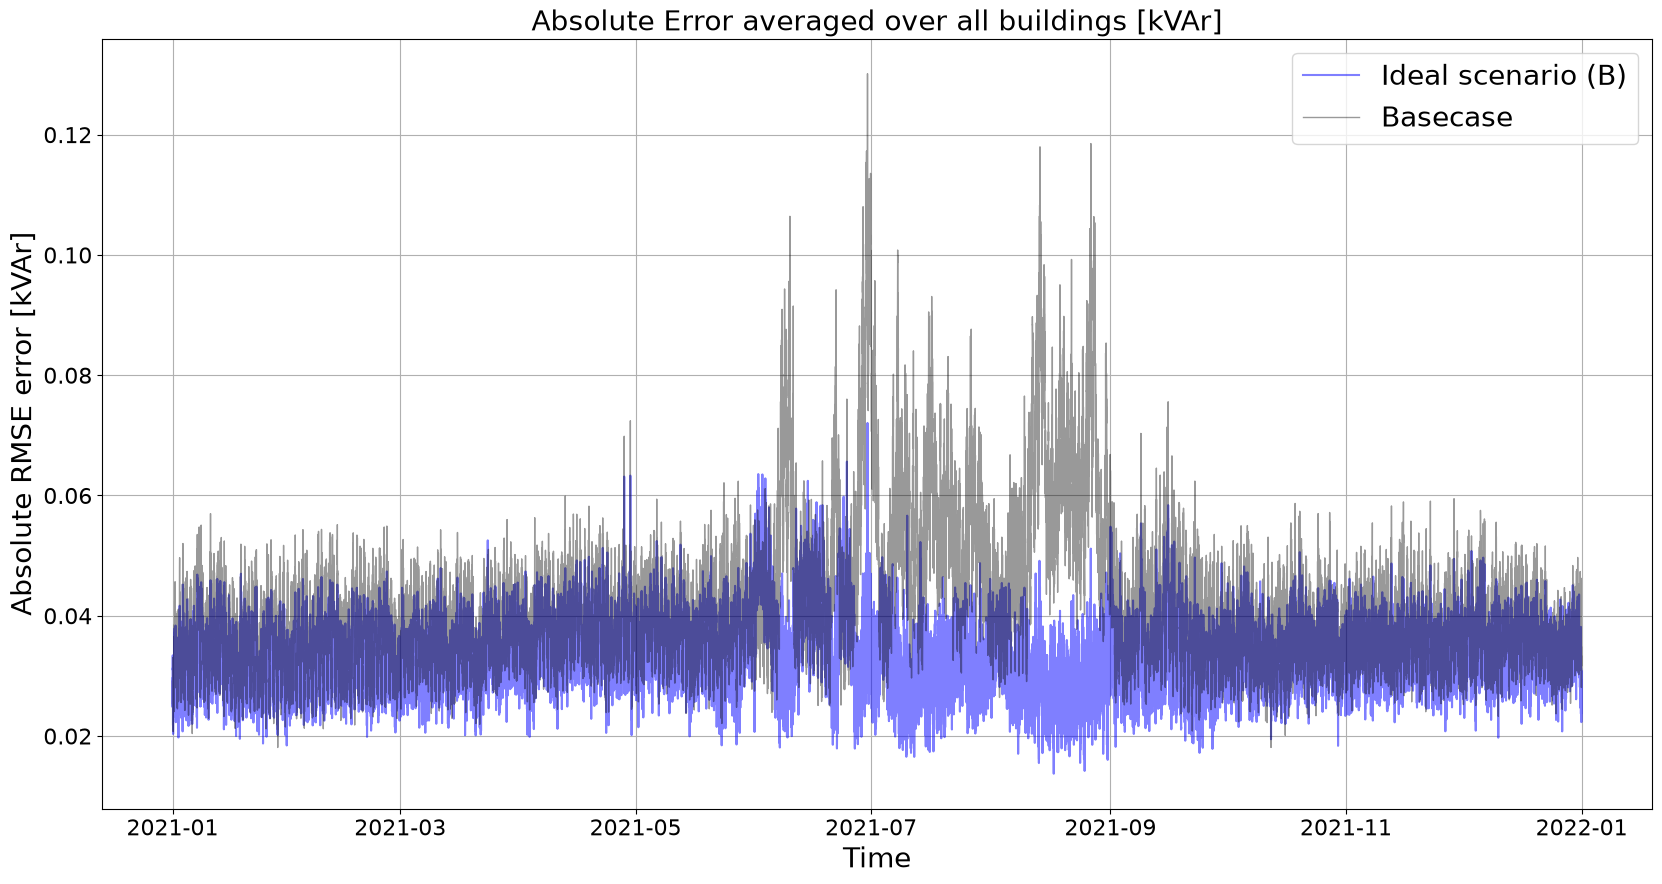

In [73]:
if input_period == "seasonal":
    error_over_time_summer = vr.error_timed_func(Summer_data, PF_list_summer, houses)
    error_over_time_fall = vr.error_timed_func(Fall_data, PF_list_fall, houses)
    error_over_time_winter = vr.error_timed_func(Winter_data, PF_list_winter, houses)
    error_over_time_spring = vr.error_timed_func(Spring_data, PF_list_spring, houses)
    tub_error_over_time_summer = vr.error_timed_func(Summer_data, tub_PF_list_summer, houses)
    tub_error_over_time_fall = vr.error_timed_func(Fall_data, tub_PF_list_fall, houses)
    tub_error_over_time_winter = vr.error_timed_func(Winter_data, tub_PF_list_winter, houses)
    tub_error_over_time_spring = vr.error_timed_func(Spring_data, tub_PF_list_spring, houses)
    basecase_error_over_time_summer = vr.Basecase_time(Summer_data, houses, best_PF)
    basecase_error_over_time_fall = vr.Basecase_time(Fall_data, houses, best_PF)
    basecase_error_over_time_winter = vr.Basecase_time(Winter_data, houses, best_PF)
    basecase_error_over_time_spring = vr.Basecase_time(Spring_data, houses, best_PF)
    error_over_time = pd.concat([error_over_time_summer, error_over_time_fall, error_over_time_winter, error_over_time_spring]).sort_index()
    error_over_time_best = pd.concat([tub_error_over_time_summer, tub_error_over_time_fall, tub_error_over_time_winter, tub_error_over_time_spring]).sort_index()
    basecase_error = pd.concat([basecase_error_over_time_summer, basecase_error_over_time_fall, basecase_error_over_time_winter, basecase_error_over_time_spring]).sort_index()
else:
    error_over_time = vr.error_timed_func(power_dict, PF_list, houses).sort_index()
    error_over_time_best = vr.error_timed_func(power_dict, tub_PF_list, houses).sort_index()
    basecase_error = vr.Basecase_time(power_dict, houses, best_PF).sort_index()

vr.error_over_time_viz(error_over_time, basecase_error, error_over_time_best, "TUB")

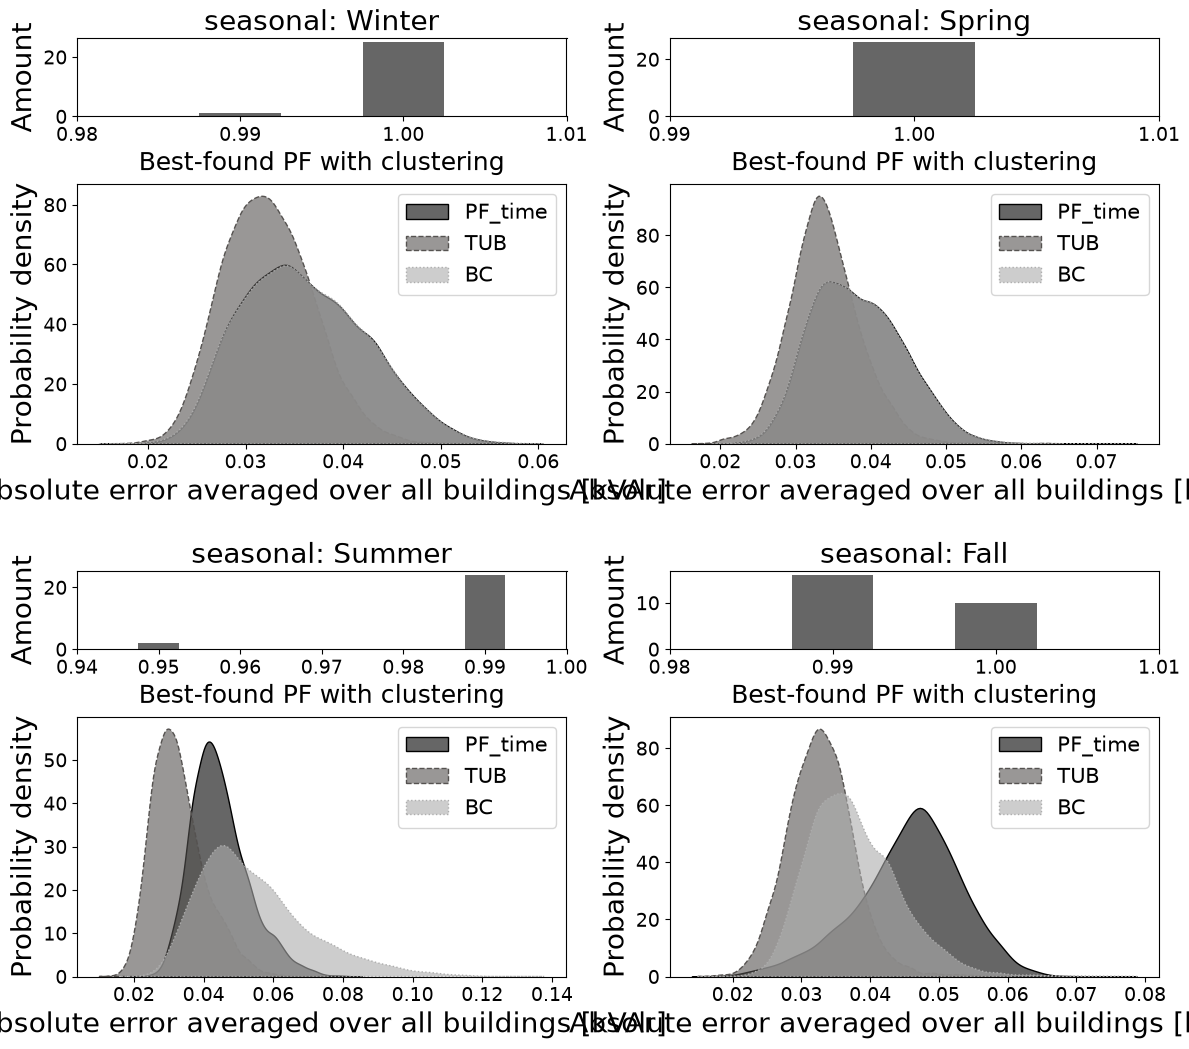

In [74]:
if input_period == "seasonal":
    size_distribution_list = [size_distribution_Summer, size_distribution_Fall, size_distribution_Winter, size_distribution_Spring]
    error_over_time_list = [error_over_time_summer, error_over_time_fall, error_over_time_winter, error_over_time_spring]
    error_over_time_best_list = [tub_error_over_time_summer, tub_error_over_time_fall, tub_error_over_time_winter, tub_error_over_time_spring]
    error_over_time_basecase_list = [basecase_error_over_time_summer, basecase_error_over_time_fall, basecase_error_over_time_winter, basecase_error_over_time_spring]
else:
    size_distribution_list = [size_distribution]
    error_over_time_list = [error_over_time]
    error_over_time_best_list = [error_over_time_best]
    error_over_time_basecase_list = [basecase_error]

vr.distribution_error_plot(size_distribution_list, error_over_time_list, error_over_time_basecase_list, error_over_time_best_list, input_period, "PF_time")